In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

In [ ]:
EXPERIMENT_DIR = Path("experiments/test")
TASKS = ["countdown", "gsm8k", "proofwriter", "hellaswag", "mmlu-pro", "arc-challenge", "piqa"]
PANEL_TASKS = ["countdown", "gsm8k", "proofwriter"]
TASK_LABELS = {
    "countdown": "Countdown",
    "gsm8k": "GSM8K",
    "proofwriter": "ProofWriter",
    "hellaswag": "HellaSwag",
    "mmlu-pro": "MMLU-Pro",
    "arc-challenge": "ARC-Challenge",
    "piqa": "PIQA",
}
RUN_MARKERS = {"ES (30)": "o", "GRPO": "X"}

RUN_CONFIGS = [
    {
        "task": "countdown",
        "title": "Countdown",
        "runs": [
            {
                "label": "ES (30)",
                "path": EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_20260315_212803",
                "kind": "ES",
            },
            {
                "label": "GRPO",
                "path": Path("grpo_experiments/runs/Qwen2.5-3B-Instruct_grpo_countdown_seed42"),
                "kind": "GRPO",
            },
        ],
    },
    {
        "task": "gsm8k",
        "title": "GSM8K",
        "runs": [
            {
                "label": "ES (30)",
                "path": EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_gsm8k_seed0_popsize30_msFalse_20260330_170126",
                "kind": "ES",
            },
            {
                "label": "GRPO",
                "path": Path("grpo_experiments/runs/Qwen2.5-3B-Instruct_grpo_gsm8k"),
                "kind": "GRPO",
            },
        ],
    },
    {
        "task": "proofwriter",
        "title": "ProofWriter",
        "runs": [
            {
                "label": "ES (30)",
                "path": EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_proofwriter_seed0_popsize30_msFalse_20260328_203835",
                "kind": "ES",
            },
            {
                "label": "GRPO",
                "path": Path("grpo_experiments/runs/Qwen2.5-3B-Instruct_grpo_proofwriter"),
                "kind": "GRPO",
            },
        ],
    },
]

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "evaluation").exists():
    if (REPO_ROOT.parent / "evaluation").exists():
        REPO_ROOT = REPO_ROOT.parent
    else:
        raise RuntimeError("Run this notebook from the repo root or evaluation directory.")

In [ ]:
def resolve_path(path: Path):
    path = Path(path)
    return path if path.is_absolute() else REPO_ROOT / path


def load_metrics(run_dir: Path, task_name: str):
    path = run_dir / f"{task_name}.jsonl"
    empty_frame = pd.DataFrame(columns=["step", f"{task_name}_accuracy"])
    if not path.is_file():
        print(f"Missing metrics file for {task_name}: {path}")
        return empty_frame, path, False

    records = [json.loads(line) for line in path.read_text().splitlines() if line.strip()]
    if not records:
        print(f"No records found in {path}")
        return empty_frame, path, False

    frame = pd.DataFrame(records).sort_values("step").reset_index(drop=True)
    frame = frame.rename(columns={"accuracy": f"{task_name}_accuracy"})
    return frame, path, True


def read_model_name(run_dir: Path, kind: str):
    if kind == "ES":
        args_path = run_dir / "args.json"
        if args_path.is_file():
            return json.loads(args_path.read_text()).get("model_name")
    if kind == "GRPO":
        model_path = run_dir / "model.txt"
        if model_path.is_file():
            return model_path.read_text().strip()
    return None


def build_run_spec(train_task: str, label: str, run_dir: Path, kind: str):
    train_df, train_path, train_available = load_metrics(run_dir, train_task)
    if train_available:
        print(f"Loaded {TASK_LABELS[train_task]} {label} train metrics: {train_path}")
    else:
        print(f"{TASK_LABELS[train_task]} {label} train metrics unavailable: {train_path}")

    eval_frames = {}
    eval_available = {}
    for task_name in [task for task in TASKS if task != train_task]:
        eval_df, eval_path, is_available = load_metrics(run_dir, task_name)
        eval_frames[task_name] = eval_df
        eval_available[task_name] = is_available
        if is_available:
            print(f"Loaded {TASK_LABELS[train_task]} {label} eval metrics: {eval_path}")
        else:
            print(f"{TASK_LABELS[train_task]} {label} eval metrics unavailable for {task_name}: {eval_path}")

    return {
        "label": label,
        "kind": kind,
        "run_dir": run_dir,
        "model_name": read_model_name(run_dir, kind),
        "marker": RUN_MARKERS[label],
        "train_df": train_df,
        "train_available": train_available,
        "eval_frames": eval_frames,
        "eval_available": eval_available,
    }


def build_panel_spec(config):
    train_task = config["task"]
    run_specs = []
    for run_config in config["runs"]:
        run_specs.append(
            build_run_spec(
                train_task=train_task,
                label=run_config["label"],
                run_dir=resolve_path(run_config["path"]),
                kind=run_config["kind"],
            )
        )

    return {
        "task": train_task,
        "title": config["title"],
        "eval_tasks": [task for task in TASKS if task != train_task],
        "run_specs": run_specs,
    }


PANEL_SPECS = [build_panel_spec(config) for config in RUN_CONFIGS]

In [ ]:
step_series = []
for panel_spec in PANEL_SPECS:
    for run_spec in panel_spec["run_specs"]:
        if not run_spec["train_df"].empty:
            step_series.append(run_spec["train_df"]["step"])
        for eval_df in run_spec["eval_frames"].values():
            if not eval_df.empty:
                step_series.append(eval_df["step"])

if step_series:
    all_steps = pd.concat(step_series, ignore_index=True)
    norm = Normalize(vmin=all_steps.min(), vmax=all_steps.max())
else:
    norm = Normalize(vmin=0, vmax=1)

LEGEND_HANDLES = [
    Line2D(
        [0],
        [0],
        marker=marker,
        linestyle="",
        markerfacecolor="0.45",
        markeredgecolor="0.25",
        markersize=8,
        label=label,
    )
    for label, marker in RUN_MARKERS.items()
]

model_names = {
    run_spec["model_name"]
    for panel_spec in PANEL_SPECS
    for run_spec in panel_spec["run_specs"]
    if run_spec["model_name"]
}
TITLE_MODEL_NAME = " | ".join(sorted(model_names))

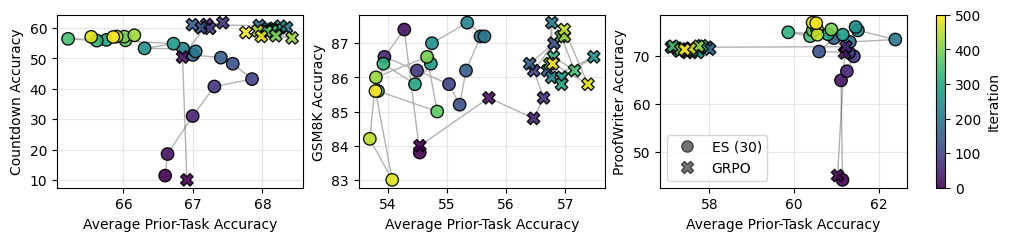

In [5]:
def average_other_task_accuracy(run_spec, eval_tasks):
    other_accuracy_frames = []
    for task_name in eval_tasks:
        accuracy_col = f"{task_name}_accuracy"
        if not run_spec["eval_available"].get(task_name, False):
            continue
        eval_df = run_spec["eval_frames"][task_name]
        if accuracy_col not in eval_df.columns:
            continue
        other_accuracy_frames.append(eval_df[["step", accuracy_col]])

    if not other_accuracy_frames:
        return pd.DataFrame(columns=["step", "avg_other_accuracy"])

    avg_other_df = other_accuracy_frames[0].copy()
    for eval_df in other_accuracy_frames[1:]:
        avg_other_df = avg_other_df.merge(eval_df, on="step", how="outer")

    accuracy_cols = [col for col in avg_other_df.columns if col != "step"]
    avg_other_df["avg_other_accuracy"] = avg_other_df[accuracy_cols].mean(axis=1)
    return avg_other_df[["step", "avg_other_accuracy"]].sort_values("step").reset_index(drop=True)


fig, axes = plt.subplots(1, 3, figsize=(10, 2.3), sharex=False, sharey=False, constrained_layout=True)
scatter_artist = None

for ax, panel_spec in zip(axes, PANEL_SPECS):
    train_task = panel_spec["task"]
    train_accuracy_col = f"{train_task}_accuracy"

    # ax.set_title(panel_spec["title"])
    ax.set_xlabel("Average Prior-Task Accuracy")
    ax.set_ylabel(f"{panel_spec['title']} Accuracy")
    ax.grid(alpha=0.3)

    plotted_any = False
    messages = []

    for run_spec in panel_spec["run_specs"]:
        if not run_spec["train_available"]:
            messages.append(f"{run_spec['label']}: missing {train_task} metrics")
            continue

        avg_other_df = average_other_task_accuracy(run_spec, panel_spec["eval_tasks"])
        if avg_other_df.empty:
            messages.append(f"{run_spec['label']}: missing eval task metrics")
            continue

        merged = run_spec["train_df"][["step", train_accuracy_col]].merge(
            avg_other_df,
            on="step",
            how="inner",
        )
        if merged.empty:
            messages.append(f"{run_spec['label']}: no overlapping steps")
            continue

        ax.plot(
            merged["avg_other_accuracy"],
            merged[train_accuracy_col],
            color="black",
            linewidth=1.0,
            alpha=0.3,
            zorder=1,
        )

        scatter_artist = ax.scatter(
            merged["avg_other_accuracy"],
            merged[train_accuracy_col],
            c=merged["step"],
            cmap="viridis",
            norm=norm,
            s=80,
            edgecolors="black",
            marker=run_spec["marker"],
            alpha=0.9,
            zorder=99,
        )
        plotted_any = True

    if not plotted_any:
        ax.text(
            0.5,
            0.5,
            "\\n".join(messages) if messages else "No data available",
            ha="center",
            va="center",
            transform=ax.transAxes,
            color="0.4",
        )

if scatter_artist is not None:
    fig.colorbar(
        scatter_artist,
        ax=axes,
        location="right",
        fraction=0.035,
        pad=0.035,
        label="Iteration",
    )

axes[-1].legend(handles=LEGEND_HANDLES, loc="lower left", ncol=1, fontsize=10)
# fig.suptitle(TITLE_MODEL_NAME)
plt.savefig("forgetting_tasks.pdf", bbox_inches="tight")
plt.show()

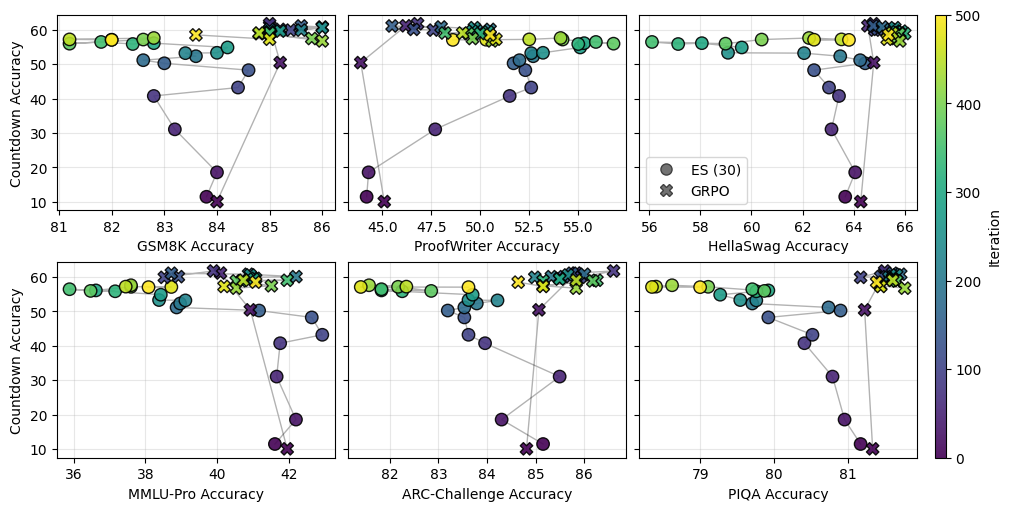

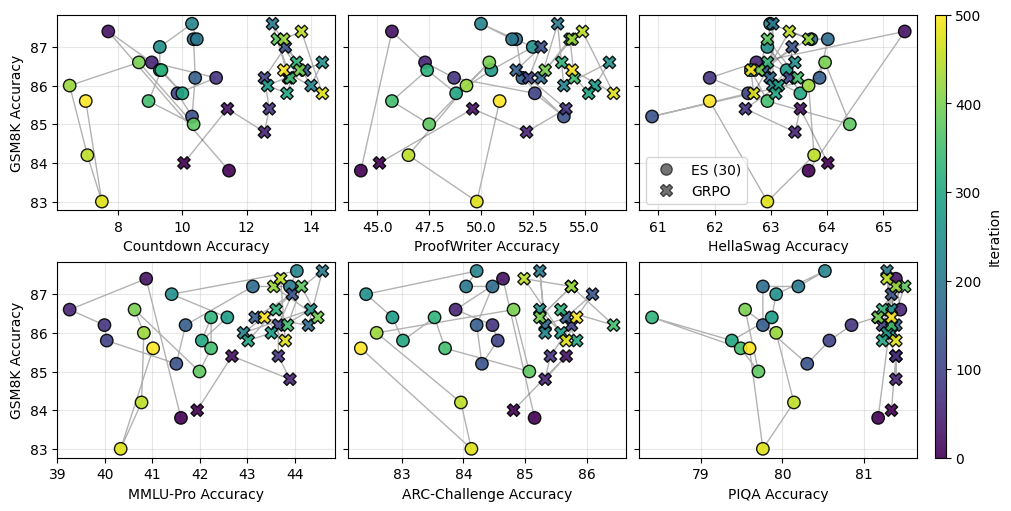

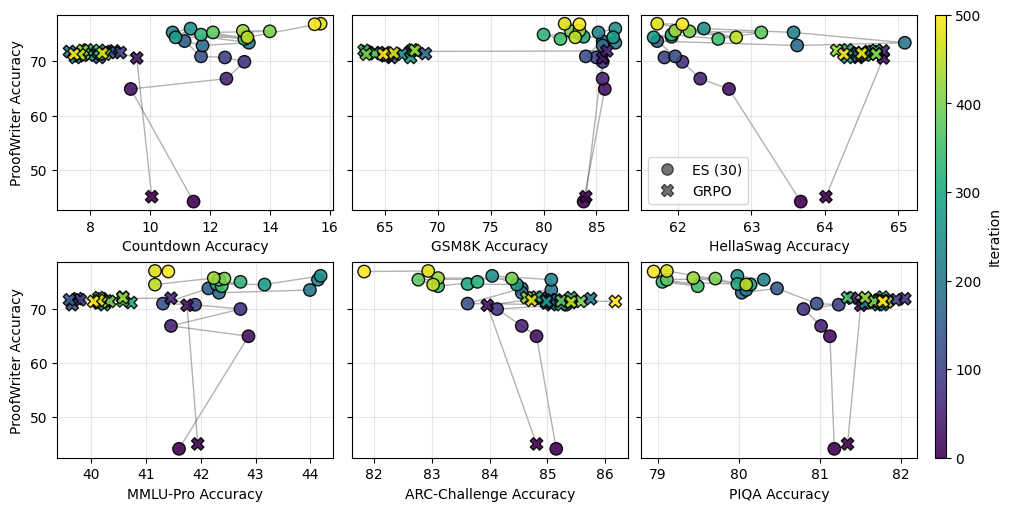

In [ ]:
def plot_individual_task_accuracies(train_task, run_pair, eval_tasks, title):
    fig, axes = plt.subplots(2, 3, figsize=(10, 5), sharey=True, constrained_layout=True)
    axes = axes.flatten().tolist()
    visible_axes = []
    scatter_artist = None

    for ax, task_name in zip(axes, eval_tasks):
        train_accuracy_col = f"{train_task}_accuracy"
        eval_accuracy_col = f"{task_name}_accuracy"

        ax.set_xlabel(f"{TASK_LABELS[task_name]} Accuracy")
        ax.grid(alpha=0.3)
        visible_axes.append(ax)

        plotted_any = False
        messages = []

        for run_spec in run_pair:
            train_df = run_spec["train_df"]
            eval_df = run_spec["eval_frames"].get(task_name, pd.DataFrame())
            train_available = run_spec["train_available"]
            eval_available = run_spec["eval_available"].get(task_name, False)

            if not train_available:
                messages.append(f"{run_spec['label']}: missing {train_task} metrics")
                continue
            if not eval_available:
                messages.append(f"{run_spec['label']}: missing {task_name} metrics")
                continue

            merged = train_df[["step", train_accuracy_col]].merge(
                eval_df[["step", eval_accuracy_col]],
                on="step",
                how="inner",
            )
            if merged.empty:
                messages.append(f"{run_spec['label']}: no overlapping steps")
                continue
            
            ax.plot(
                merged[eval_accuracy_col],
                merged[train_accuracy_col],
                color="black",
                linewidth=1.0,
                alpha=0.3,
                zorder=1,
            )

            scatter_artist = ax.scatter(
                merged[eval_accuracy_col],
                merged[train_accuracy_col],
                c=merged["step"],
                cmap="viridis",
                norm=norm,
                s=80,
                edgecolors="black",
                marker=run_spec["marker"],
                alpha=0.9,
                zorder=99,
            )
            plotted_any = True

        if not plotted_any:
            ax.text(
                0.5,
                0.5,
                "\n".join(messages) if messages else "No data available",
                ha="center",
                va="center",
                transform=ax.transAxes,
                color="0.4",
            )

    for ax in axes[len(eval_tasks):]:
        ax.set_visible(False)

    if visible_axes:
        visible_axes[0].set_ylabel(f"{TASK_LABELS[train_task]} Accuracy")
        if len(visible_axes) > 3:
            visible_axes[3].set_ylabel(f"{TASK_LABELS[train_task]} Accuracy")

    if scatter_artist is not None:
        fig.colorbar(
            scatter_artist,
            ax=visible_axes,
            location="right",
            fraction=0.035,
            pad=0.02,
            label="Iteration",
            aspect=40
        )

    axes[2].legend(handles=LEGEND_HANDLES, loc="lower left", ncol=1)
    plt.savefig(f"forgetting_tasks_individual_{train_task}.pdf", bbox_inches="tight")
    plt.show()

plot_individual_task_accuracies(
    train_task=PANEL_SPECS[0]["task"],
    run_pair=tuple(PANEL_SPECS[0]["run_specs"]),
    eval_tasks=PANEL_SPECS[0]["eval_tasks"],
    title=PANEL_SPECS[0]["title"],
)
plot_individual_task_accuracies(
    train_task=PANEL_SPECS[1]["task"],
    run_pair=tuple(PANEL_SPECS[1]["run_specs"]),
    eval_tasks=PANEL_SPECS[1]["eval_tasks"],
    title=PANEL_SPECS[1]["title"],
)
plot_individual_task_accuracies(
    train_task=PANEL_SPECS[2]["task"],
    run_pair=tuple(PANEL_SPECS[2]["run_specs"]),
    eval_tasks=PANEL_SPECS[2]["eval_tasks"],
    title=PANEL_SPECS[2]["title"],
)